sentiment                    negative  neutral  positive
bank                                                    
Bank of Abyssinia                 108      178       314
Commercial Bank of Ethiopia        62      138       400
Dashen Bank                        84      125       391


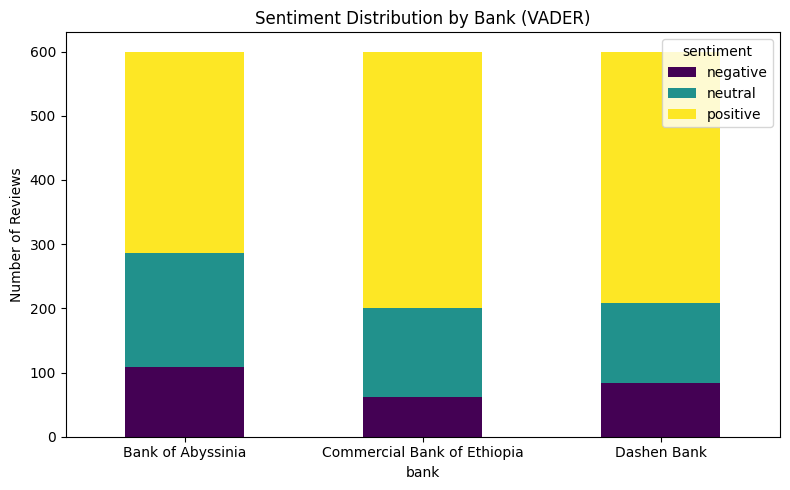

In [5]:
# %% [markdown]
# # Task 2 – Preliminary Sentiment Analysis
# Early sentiment findings using VADER.

# %%
import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv('../data/raw/reviews_clean.csv')

# %%
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['review'].apply(vader_sentiment)

# %%
sentiment_counts = df.groupby(['bank', 'sentiment']).size().unstack(fill_value=0)
print(sentiment_counts)

# %%
ax = sentiment_counts.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8,5))
plt.title('Sentiment Distribution by Bank (VADER)')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_by_bank_vader.png')   # save to include in report
plt.show()

In [6]:
# Overall sentiment percentages (all banks)
sentiment_totals = df['sentiment'].value_counts(normalize=True) * 100
pos = sentiment_totals.get('positive', 0.0)
neg = sentiment_totals.get('negative', 0.0)
neu = sentiment_totals.get('neutral', 0.0)

print("Overall sentiment :\n")
print(f"Positive: [{pos:5.1f}%]\n")
print(f"Negative: [{neg:5.1f}%]\n")
print(f"Neutral:  [{neu:5.1f}%]\n")

Overall sentiment :

Positive: [ 61.4%]

Negative: [ 14.1%]

Neutral:  [ 24.5%]

